NLP Sentiment Analysis — Exploratory Data Analysis (EDA)

Project:Extracting sentiment from customer reviews of a Samsung mobile phone (scraped from Amazon)

1. Setup & Imports

In [ ]:
pip install wordcloud

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from wordcloud import WordCloud

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_colwidth", 120)


2. Load the Dataset

In [ ]:
df = pd.read_excel("/content/dataset.xlsx")
print("Shape:", df.shape)
df.head()


Shape: (1440, 3)


,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance from Samsung
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must be appreciatedCamera is just averageMobile performance is above avera..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency. 2.4GHz is very old school.2. Camera quality is pathetic (both front a...
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor display quality, single band wifi doesn't support 5ghz WIFI band. Gyro se..."


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


In [ ]:
#3. Data Quality Checks

#Checking for missing values, duplicate rows, and unusually short reviews.

In [ ]:
print("Missing values per column:")
print(df.isna().sum())

print("\nFully duplicated rows:", df.duplicated().sum())
print("Duplicated titles (top 10):")
print(df['title'].value_counts().head(10))


Missing values per column:
title     0
rating    0
body      0
dtype: int64

Fully duplicated rows: 0
Duplicated titles (top 10):
title
Value for money      16
Good                  6
Average               6
Waste of money        6
Awesome phone         5
Good product          5
Good phone            5
Excellent             4
Best budget phone     3
Honest review         3
Name: count, dtype: int64


In [ ]:

df['body'] = df['body'].astype(str)
df['title'] = df['title'].astype(str)

# Flag very short review bodies (low-signal, e.g. "Like" / "Dislike")
df['body_char_len'] = df['body'].str.len()
short_reviews = df[df['body_char_len'] < 15]
print(f"Reviews with body shorter than 15 characters: {len(short_reviews)}")
short_reviews[['title', 'rating', 'body']]


Reviews with body shorter than 15 characters: 5


,title,rating,body
15,Hitting issue,1,Hitting issue
21,Very poor performance,1,Dislike
521,Samsung mobile is best,5,Best mobile
717,M12,5,Nice phone...
1106,Good,5,Like


4. Rating Distribution

The star rating (1-5) is the raw signal we'll use to derive sentiment labels.

rating
1    386
2    126
3    199
4    310
5    419
Name: count, dtype: int64


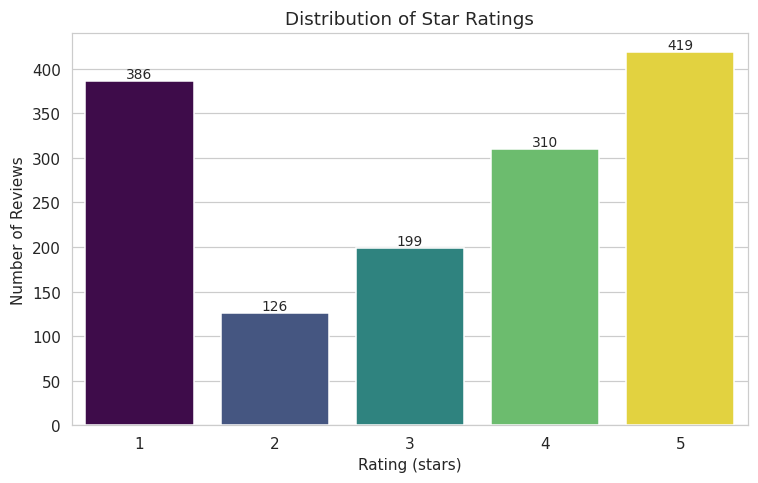

In [ ]:
rating_counts = df['rating'].value_counts().sort_index()
print(rating_counts)

plt.figure(figsize=(7,4.5))
ax = sns.countplot(data=df, x='rating', hue='rating', palette='viridis', legend=False,
                    order=[1,2,3,4,5])
ax.set_title("Distribution of Star Ratings")
ax.set_xlabel("Rating (stars)")
ax.set_ylabel("Number of Reviews")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


Observation: Ratings follow a U-shaped / bimodal distribution — the majority of reviews are either 1-star or 5-star, with fewer reviews in the middle (2-3 stars). This is typical of e-commerce review data: customers are most motivated to write a review when they are either delighted or very unhappy.

5. Deriving Sentiment Labels from Rating

Since there's no explicit sentiment column, we derive one from `rating` using the standard convention:

- 1-2 stars → Negative
- 3 stars → Neutral
- 4-5 stars → Positive

This derived label will serve as our target variable for the sentiment classification model in the next milestone.

In [ ]:
def rating_to_sentiment(r):
    if r <= 2:
        return "negative"
    elif r == 3:
        return "neutral"
    else:
        return "positive"

df['sentiment'] = df['rating'].apply(rating_to_sentiment)

sentiment_counts = df['sentiment'].value_counts()
sentiment_pct = df['sentiment'].value_counts(normalize=True).mul(100).round(1)

print(sentiment_counts)
print()
print(sentiment_pct.astype(str) + "%")


sentiment
positive    729
negative    512
neutral     199
Name: count, dtype: int64

sentiment
positive    50.6%
negative    35.6%
neutral     13.8%
Name: proportion, dtype: object


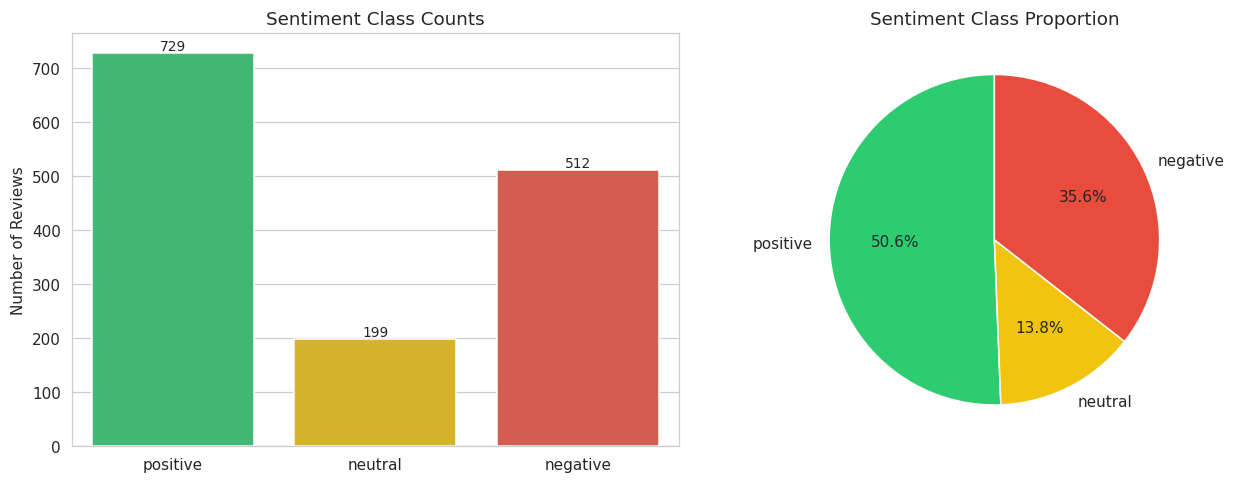

In [ ]:
order = ['positive', 'neutral', 'negative']
colors = {'positive': '#2ecc71', 'neutral': '#f1c40f', 'negative': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(12,4.5))

sns.countplot(data=df, x='sentiment', hue='sentiment', order=order,
              palette=colors, legend=False, ax=axes[0])
axes[0].set_title("Sentiment Class Counts")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of Reviews")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                      ha='center', va='bottom', fontsize=9)

axes[1].pie(sentiment_counts[order], labels=order, autopct='%1.1f%%',
            colors=[colors[s] for s in order], startangle=90)
axes[1].set_title("Sentiment Class Proportion")

plt.tight_layout()
plt.show()


Observation: There is a moderate class imbalance — Positive (~50%) and Negative (~36%) dominate, while Neutral is under-represented (~14%). This should be accounted for during model training (e.g. stratified train/test split, class weighting, or resampling techniques such as SMOTE) to avoid a model that is biased toward the majority classes.

6. Review Text Length Analysis

In [ ]:
df['title_char_len'] = df['title'].str.len()
df['title_word_count'] = df['title'].str.split().str.len()
df['body_word_count'] = df['body'].str.split().str.len()

df[['title_char_len', 'body_char_len', 'title_word_count', 'body_word_count']].describe()


,title_char_len,body_char_len,title_word_count,body_word_count
count,1440.000000,1440.000000,1440.000000,1440.000000
mean,30.272917,302.109028,5.365278,52.892361
std,18.517534,225.733052,3.377548,39.346259
min,3.000000,4.000000,1.000000,1.000000
25%,16.000000,170.000000,3.000000,29.000000
50%,26.000000,246.000000,5.000000,43.000000
75%,38.000000,359.000000,7.000000,63.250000
max,100.000000,2490.000000,22.000000,385.000000


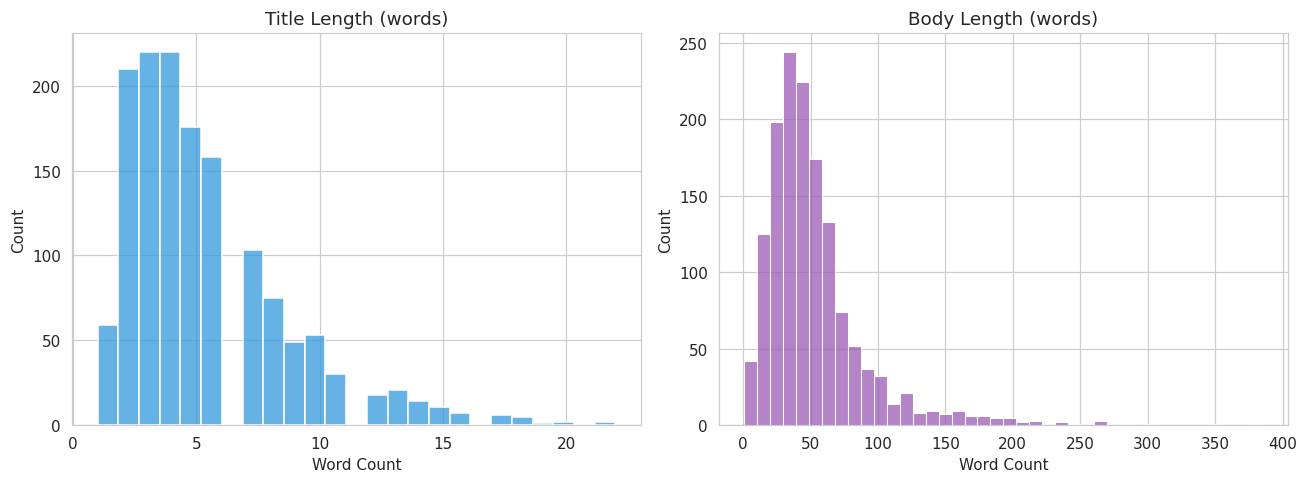

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))

sns.histplot(df['title_word_count'], bins=25, color='#3498db', ax=axes[0])
axes[0].set_title("Title Length (words)")
axes[0].set_xlabel("Word Count")

sns.histplot(df['body_word_count'], bins=40, color='#9b59b6', ax=axes[1])
axes[1].set_title("Body Length (words)")
axes[1].set_xlabel("Word Count")

plt.tight_layout()
plt.show()


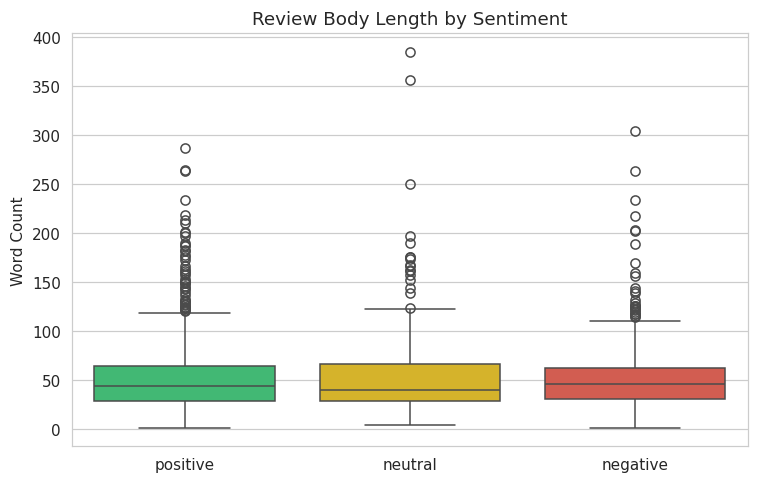

In [ ]:
plt.figure(figsize=(7,4.5))
sns.boxplot(data=df, x='sentiment', y='body_word_count', hue='sentiment',
            order=order, palette=colors, legend=False)
plt.title("Review Body Length by Sentiment")
plt.xlabel("")
plt.ylabel("Word Count")
plt.tight_layout()
plt.show()


Observation: Review bodies average ~50 words but range widely (a handful of one-word reviews up to very long ones). Negative reviews tend to run a bit longer on average than positive ones — dissatisfied customers often explain their complaints in more detail.

7. Most Frequent Words by Sentiment

Basic word-frequency analysis (lowercased, punctuation stripped, common stopwords removed) to see what customers talk about most in each sentiment class.

In [ ]:
STOPWORDS = set('''
the a an and or is are was were to of in on for this that with i my it its as be have has not
very but you your yours it's im i'm they their them he she his her we our us at so if than then
from will would could should can just also all get got one really only more most much no
'''.split())

def clean_words(text):
    words = re.findall(r"[a-zA-Z']+", str(text).lower())
    return [w for w in words if w not in STOPWORDS and len(w) > 2]

df['clean_body_words'] = df['body'].apply(clean_words)

top_words_by_sentiment = {}
for s in order:
    counter = Counter()
    for words in df.loc[df['sentiment'] == s, 'clean_body_words']:
        counter.update(words)
    top_words_by_sentiment[s] = counter.most_common(15)
    print(f"\nTop 15 words — {s.upper()}:")
    for word, cnt in top_words_by_sentiment[s]:
        print(f"  {word:<15} {cnt}")



Top 15 words — POSITIVE:
  good            884
  phone           768
  camera          567
  battery         536
  quality         324
  samsung         269
  price           252
  life            213
  mobile          180
  display         163
  great           159
  best            157
  use             156
  like            136
  overall         135

Top 15 words — NEUTRAL:
  phone           215
  good            170
  camera          156
  quality         110
  battery         110
  mobile          94
  samsung         89
  average         50
  better          49
  price           47
  other           44
  screen          42
  heavy           42
  display         39
  like            37

Top 15 words — NEGATIVE:
  phone           539
  samsung         306
  camera          248
  mobile          244
  quality         198
  amazon          163
  product         163
  battery         156
  buy             151
  good            150
  don't           122
  worst           116
  like   

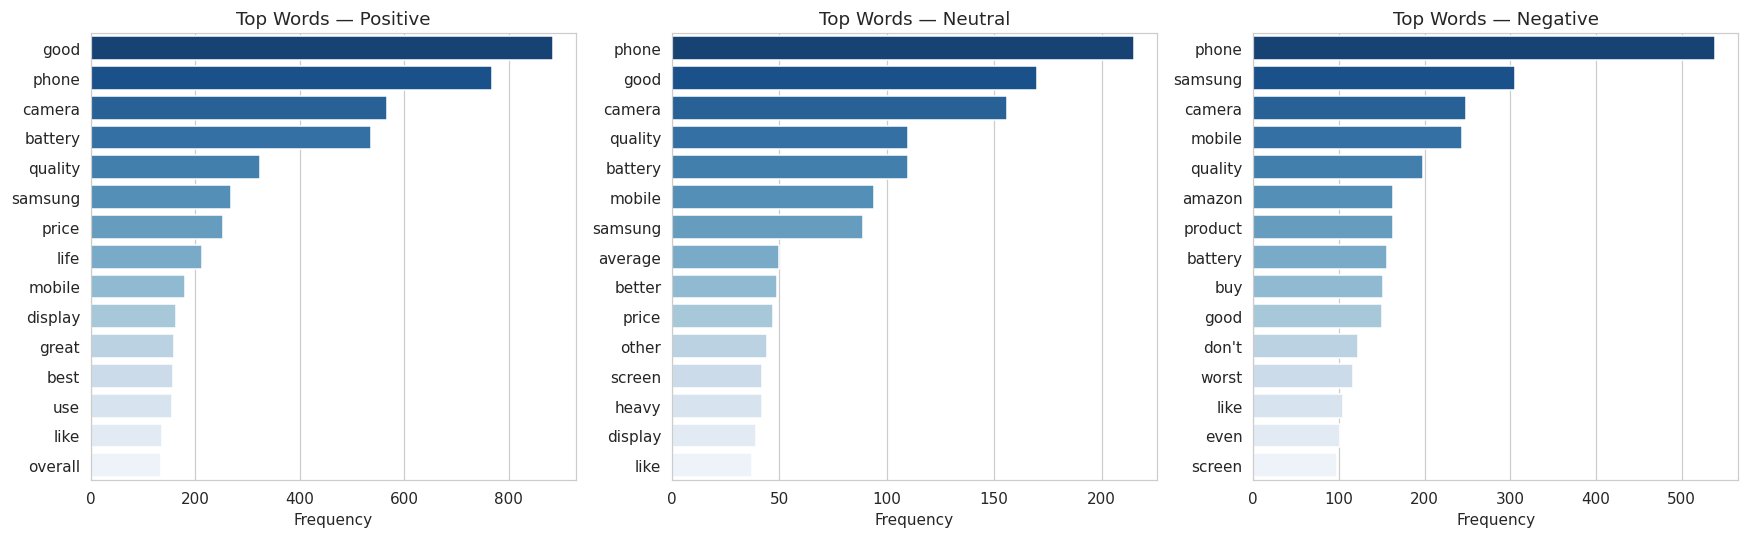

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))
for ax, s in zip(axes, order):
    words, counts = zip(*top_words_by_sentiment[s])
    sns.barplot(x=list(counts), y=list(words), hue=list(words), ax=ax,
                palette='Blues_r', legend=False)
    ax.set_title(f"Top Words — {s.capitalize()}")
    ax.set_xlabel("Frequency")
plt.tight_layout()
plt.show()


Observation: `phone`, `camera`, `battery`, and `quality` dominate across all sentiment classes — these are the core product attributes customers discuss, regardless of whether they're happy or unhappy. What differentiates the classes is the surrounding language: positive reviews pair these nouns with words like *good*, *great*, *best*; negative reviews pair them with *worst*, *waste*, *don't*; neutral reviews lean on hedging words like *average* and *better*.

8. Word Clouds by Sentiment

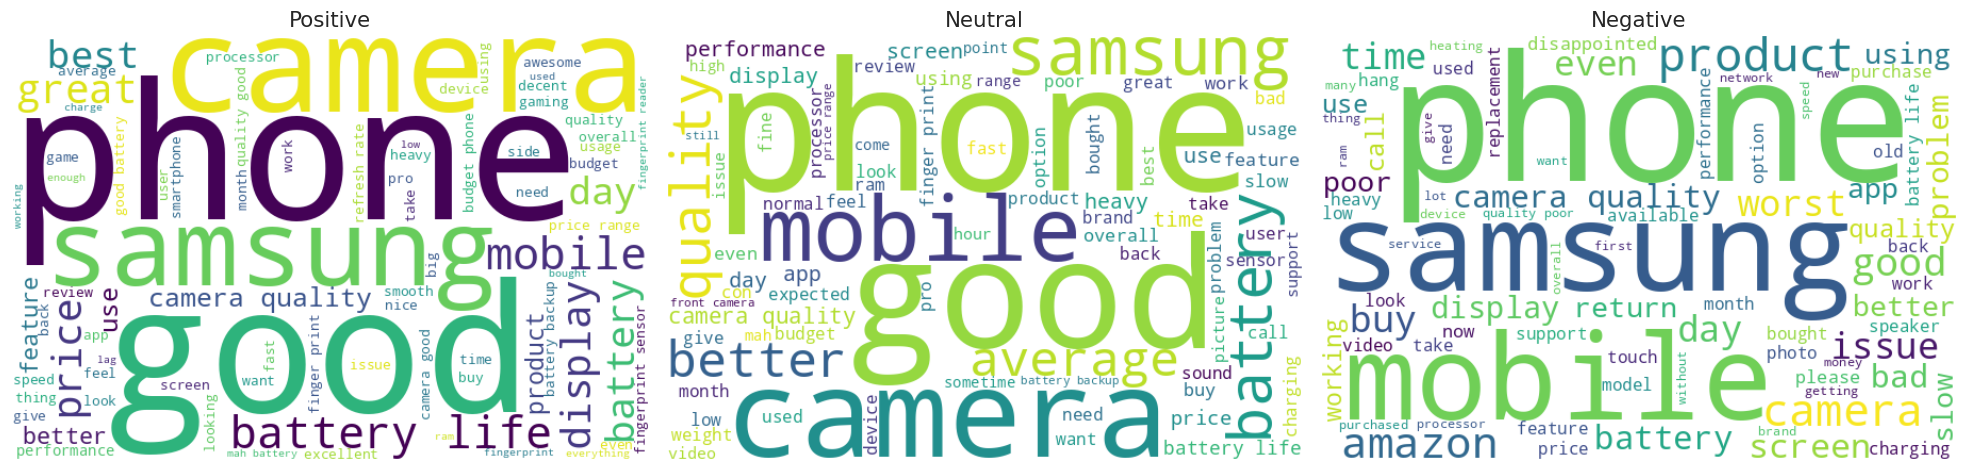

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))
for ax, s in zip(axes, order):
    text = " ".join(w for words in df.loc[df['sentiment'] == s, 'clean_body_words'] for w in words)
    wc = WordCloud(width=600, height=400, background_color='white',
                    colormap='viridis', max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(s.capitalize(), fontsize=14)
plt.tight_layout()
plt.show()


9. Does Review Length Relate to Rating?

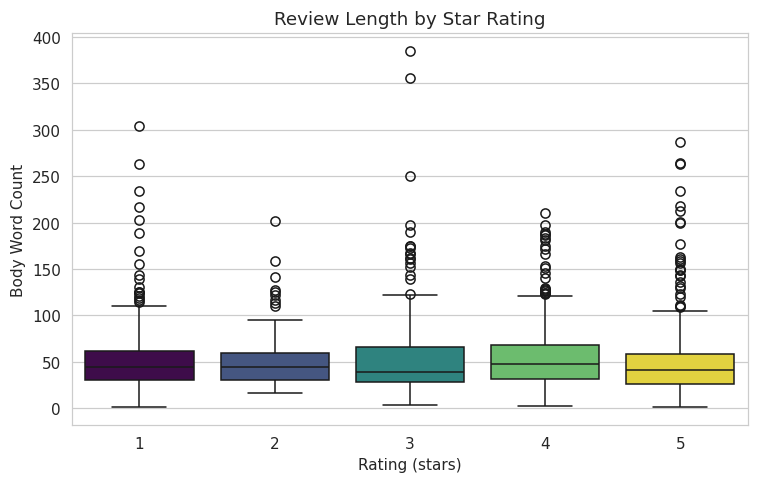

rating
1    52.3
2    51.7
3    56.5
4    56.6
5    49.3
Name: body_word_count, dtype: float64


In [ ]:
plt.figure(figsize=(7,4.5))
sns.boxplot(data=df, x='rating', y='body_word_count', hue='rating',
            palette='viridis', legend=False)
plt.title("Review Length by Star Rating")
plt.xlabel("Rating (stars)")
plt.ylabel("Body Word Count")
plt.tight_layout()
plt.show()

print(df.groupby('rating')['body_word_count'].mean().round(1))


10. Summary of EDA Findings

1. **1,440 reviews**, no missing values, no fully duplicated rows. A very small number of reviews have near-empty bodies (e.g. "Like" / "Dislike") and should be handled during cleaning.
2. **Ratings are U-shaped / bimodal** — most reviews are 1-star or 5-star, fewer in the 2-3 star range.
3. Deriving sentiment from rating gives a **moderate class imbalance**: Positive ~51%, Negative ~36%, Neutral ~14%. This needs to be addressed during model training.
4. **Review bodies average ~50 words**, with negative reviews trending slightly longer than positive ones.
5. Across all sentiment classes, discussion centers on the same product attributes — **phone, camera, battery, quality** — with sentiment-bearing adjectives (*good/great/best* vs. *worst/waste*) being the main differentiator.
6. Titles are short and often generic/repetitive (e.g. "Value for money" appears 16 times), so titles alone will be a weak feature; the review `body` is the primary signal for the sentiment model.

# Part 2: Feature Engineering and Model Evaluation



1. Preserved important negation words such as **not**, **no**, **never**, and **nor** because they can change the meaning of a review.

2. Kept the original review text separately from the cleaned text so that punctuation and capitalization information could still be used as features.

## 11. Experimental Limitation: Rating-Derived Labels

The dataset gives star ratings, but it does not provide a separate human-written sentiment label. So we created the sentiment classes from the ratings using a simple rule:

- **1–2 stars → Negative**
- **3 stars → Neutral**
- **4–5 stars → Positive**

In [ ]:
# imports
import os
import re
import joblib


from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5

np.random.seed(RANDOM_STATE)

print("Random state:", RANDOM_STATE)
print("Cross-validation folds:", CV_FOLDS)

Random state: 42
Cross-validation folds: 5


## 12. Improved Text Cleaning

In this version, we converted the text to a consistent form, remove unnecessary characters and extra spaces, and perform tokenization and lemmatization. However, we intentionally keep important negation words such as **not**, **no**, **never**, and **nor**.

The cleaned text is then used for the TF-IDF representation.

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")

lemmatizer = WordNetLemmatizer()
# Preserve important negation words during sentiment preprocessing.
NEGATION_WORDS = {"no", "not", "nor", "never", "neither"}
NLP_STOPWORDS = set(stopwords.words("english")) - NEGATION_WORDS

def clean_text_pipeline(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^\w\s']", " ", text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in NLP_STOPWORDS and len(t) > 1]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

df["raw_text"] = df["title"].astype(str) + " " + df["body"].astype(str)
df["clean_text"] = df["raw_text"].apply(clean_text_pipeline)

# Check for reviews that become empty after preprocessing.
empty_clean = df["clean_text"].str.strip().eq("").sum()
print("Empty reviews after cleaning:", empty_clean)

display(df[["raw_text", "clean_text"]].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Empty reviews after cleaning: 0


,raw_text,clean_text
0,Horrible product Very disappointed with the overall performance from Samsung,horrible product disappointed overall performance samsung
1,Camera quality is not like 48 megapixel Camera quality is low,camera quality not like 48 megapixel camera quality low
2,"Overall Got the mobile on the launch date,Battery must be appreciatedCamera is just averageMobile performance is abo...",overall got mobile launch date battery must appreciatedcamera averagemobile performance average90hz refresh rate buy...
3,A big no from me 1. It doesn't work with 5.0GHz WiFi frequency. 2.4GHz is very old school.2. Camera quality is pathe...,big no work 0ghz wifi frequency 4ghz old school camera quality pathetic front back forget 48mp picture blur poorer 4...
4,"Put your money somewhere else Not worth buying....faulty software, poor display quality, single band wifi doesn't su...",put money somewhere else not worth buying faulty software poor display quality single band wifi support 5ghz wifi ba...


## 13. Handcrafted Features from Raw Text

Along with TF-IDF, I created a few simple numerical features from the original review text.

These features include:

- Character count
- Word count
- Average word length
- Number of exclamation marks
- Number of uppercase words
- Number of digits

I calculate these features from the **raw text** instead of the cleaned text. This is important because cleaning could remove information such as `!` or capitalization.

For example, a review containing **“AMAZING!!!”** may express stronger emotion than a normal sentence. These numerical features allow the model to use some of that additional information along with the TF-IDF features.

In [ ]:
def create_numeric_features(text):
    text = str(text)
    words = text.split()
    word_count = len(words)
    char_count = len(text)

    return {
        "char_count": char_count,
        "word_count": word_count,
        "avg_word_length": char_count / word_count if word_count else 0,
        "exclamation_count": text.count("!"),
        "uppercase_word_count": sum(
            1 for word in words if word.isupper() and len(word) > 1
        ),
        "digit_count": sum(character.isdigit() for character in text)
    }

numeric_features_df = pd.DataFrame(
    df["raw_text"].apply(create_numeric_features).tolist(),
    index=df.index
)

numeric_feature_cols = numeric_features_df.columns.tolist()
df[numeric_feature_cols] = numeric_features_df

display(df[numeric_feature_cols].describe())

,char_count,word_count,avg_word_length,exclamation_count,uppercase_word_count,digit_count
count,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000
mean,333.381944,58.257639,5.813334,0.233333,1.089583,4.097917
std,229.116704,39.896874,1.129827,1.219371,4.713283,7.125559
min,9.000000,2.000000,4.173913,0.000000,0.000000,0.000000
25%,198.000000,34.000000,5.400000,0.000000,0.000000,0.000000
50%,277.000000,49.000000,5.691249,0.000000,0.000000,2.000000
75%,395.000000,70.000000,6.062047,0.000000,1.000000,6.000000
max,2536.000000,391.000000,40.111111,23.000000,89.000000,124.000000


## 14. Train/Test Split

split the dataset into two parts: a training set and a final test set.

The **training set** is used for preprocessing decisions, cross-validation, hyperparameter tuning, and model selection. The **test set is kept untouched** during these steps.

In [ ]:
label_encoder = LabelEncoder()
df["sentiment_encoded"] = label_encoder.fit_transform(df["sentiment"])

model_columns = ["clean_text"] + numeric_feature_cols
X = df[model_columns].copy()
y = df["sentiment_encoded"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

print("\nTraining class distribution:")
print(
    pd.Series(y_train)
    .map(dict(enumerate(label_encoder.classes_)))
    .value_counts(normalize=True)
    .rename("proportion")
    .round(3)
)

print("\nTest class distribution:")
print(
    pd.Series(y_test)
    .map(dict(enumerate(label_encoder.classes_)))
    .value_counts(normalize=True)
    .rename("proportion")
    .round(3)
)

Training samples: 1152
Test samples: 288

Training class distribution:
sentiment_encoded
positive    0.506
negative    0.356
neutral     0.138
Name: proportion, dtype: float64

Test class distribution:
sentiment_encoded
positive    0.507
negative    0.354
neutral     0.139
Name: proportion, dtype: float64


## 15. Leakage-Safe Feature Transformer

One important improvement I made is preventing data leakage during cross-validation.

TF-IDF learns information from the text, and the numerical features are also scaled before being given to some models. If these steps are fitted using the complete dataset before cross-validation, information from the validation portion can indirectly influence the training process.

To avoid this, I placed the preprocessing steps inside the model pipeline. During every cross-validation fold, the preprocessing is fitted only on that fold's training portion and then applied to its validation portion.

This gives me a more trustworthy estimate of model performance.

In [ ]:
def make_preprocessor(use_numeric=True):
    transformers = [
        (
            "tfidf",
            TfidfVectorizer(
                max_features=5000,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.90,
                sublinear_tf=True
            ),
            "clean_text"
        )
    ]

    if use_numeric:
        transformers.append(
            (
                "numeric",
                MinMaxScaler(),
                numeric_feature_cols
            )
        )

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop"
    )

cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("Leakage-safe preprocessing and", CV_FOLDS, "-fold stratified CV are ready.")

Leakage-safe preprocessing and 5 -fold stratified CV are ready.


## 16. Model Tuning — Same Features, Same CV

compare four different machine learning approaches:

1. Logistic Regression
2. Multinomial Naive Bayes
3. Linear SVM
4. MLP Neural Network

In [ ]:
models_and_grids = {
    "Logistic Regression": (
        LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        ),
        {
            "model__C": [0.5, 1.0, 2.0],
            "model__class_weight": [None, "balanced"]
        }
    ),
    "Naive Bayes": (
        MultinomialNB(),
        {
            "model__alpha": [0.25, 0.5, 1.0, 2.0]
        }
    ),
    "Linear SVM": (
        LinearSVC(random_state=RANDOM_STATE),
        {
            "model__C": [0.5, 1.0, 2.0],
            "model__class_weight": [None, "balanced"]
        }
    ),
    "MLP": (
        MLPClassifier(
            max_iter=100,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=8,
            random_state=RANDOM_STATE
        ),
        {
            "model__hidden_layer_sizes": [(64,), (128,), (128, 64)],
            "model__alpha": [1e-4, 1e-3],
            "model__learning_rate_init": [1e-3]
        }
    )
}

tuned_models = {}
tuning_rows = []

for model_name, (estimator, param_grid) in models_and_grids.items():
    print(f"\nTuning {model_name} ...")

    pipeline = Pipeline([
        ("preprocessor", make_preprocessor(use_numeric=True)),
        ("model", estimator)
    ])

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        refit=True,
        verbose=0
    )

    search.fit(X_train, y_train)

    tuned_models[model_name] = search.best_estimator_

    tuning_rows.append({
        "Model": model_name,
        "Best CV Macro-F1": search.best_score_,
        "Best Parameters": search.best_params_
    })

    print("Best CV Macro-F1:", round(search.best_score_, 4))
    print("Best parameters:", search.best_params_)

tuning_df = pd.DataFrame(tuning_rows).sort_values(
    "Best CV Macro-F1", ascending=False
).reset_index(drop=True)

display(tuning_df)


Tuning Logistic Regression ...
Best CV Macro-F1: 0.6905
Best parameters: {'model__C': 0.5, 'model__class_weight': 'balanced'}

Tuning Naive Bayes ...
Best CV Macro-F1: 0.5541
Best parameters: {'model__alpha': 0.25}

Tuning Linear SVM ...
Best CV Macro-F1: 0.6573
Best parameters: {'model__C': 1.0, 'model__class_weight': 'balanced'}

Tuning MLP ...
Best CV Macro-F1: 0.5864
Best parameters: {'model__alpha': 0.0001, 'model__hidden_layer_sizes': (128,), 'model__learning_rate_init': 0.001}


,Model,Best CV Macro-F1,Best Parameters
0,Logistic Regression,0.690482,"{'model__C': 0.5, 'model__class_weight': 'balanced'}"
1,Linear SVM,0.657260,"{'model__C': 1.0, 'model__class_weight': 'balanced'}"
2,MLP,0.586393,"{'model__alpha': 0.0001, 'model__hidden_layer_sizes': (128,), 'model__learning_rate_init': 0.001}"
3,Naive Bayes,0.554138,{'model__alpha': 0.25}


## 17. Final Evaluation

After model tuning is completed, we evaluate the selected models on the test set that was kept aside from the beginning.

we use **Macro-F1** as an important metric because my sentiment classes are not perfectly balanced, especially the Neutral class. Macro-F1 gives equal importance to each class instead of allowing the larger Positive class to dominate the result.

we still report accuracy because it is easy to understand, but I do not use accuracy alone to decide which model is best.

In [ ]:
evaluation_rows = []
predictions = {}

for model_name, model in tuned_models.items():
    pred = model.predict(X_test)
    predictions[model_name] = pred

    evaluation_rows.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, pred),
        "Macro Precision": precision_score(y_test, pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_test, pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_test, pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_test, pred, average="weighted", zero_division=0)
    })

evaluation_df = pd.DataFrame(evaluation_rows).sort_values(
    ["Macro F1", "Accuracy"],
    ascending=False
).reset_index(drop=True)

display(evaluation_df.round(4))

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Linear SVM,0.7708,0.6615,0.6450,0.6449,0.7554
1,Logistic Regression,0.7361,0.6424,0.6475,0.6442,0.7409
2,Naive Bayes,0.7882,0.8638,0.6080,0.5775,0.7337
3,MLP,0.7708,0.5169,0.5896,0.5497,0.7126


## 18. Detailed Classification Reports

Here we look at the performance of each model separately for Negative, Neutral, and Positive sentiment.

For each class, we check:

- **Precision:** When the model predicts a class, how often is it correct?
- **Recall:** How many of the actual examples of that class did the model find?
- **F1-score:** A combined measure of precision and recall.

This helps me identify whether a model performs well for all three sentiment classes or mainly performs well because of the larger Positive class.

In [ ]:
for model_name, pred in predictions.items():
    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)
    print(
        classification_report(
            y_test,
            pred,
            target_names=label_encoder.classes_,
            digits=4,
            zero_division=0
        )
    )


Logistic Regression
              precision    recall  f1-score   support

    negative     0.7547    0.7843    0.7692       102
     neutral     0.3111    0.3500    0.3294        40
    positive     0.8613    0.8082    0.8339       146

    accuracy                         0.7361       288
   macro avg     0.6424    0.6475    0.6442       288
weighted avg     0.7471    0.7361    0.7409       288


Naive Bayes
              precision    recall  f1-score   support

    negative     0.8252    0.8333    0.8293       102
     neutral     1.0000    0.0250    0.0488        40
    positive     0.7663    0.9658    0.8545       146

    accuracy                         0.7882       288
   macro avg     0.8638    0.6080    0.5775       288
weighted avg     0.8196    0.7882    0.7337       288


Linear SVM
              precision    recall  f1-score   support

    negative     0.7456    0.8333    0.7870       102
     neutral     0.3913    0.2250    0.2857        40
    positive     0.8477    0.

## 19. Confusion Matrices

The confusion matrix shows where the model's predictions are correct and where it makes mistakes.

For example, it can show whether Negative reviews are being confused with Neutral reviews, or whether Neutral reviews are being incorrectly classified as Positive.

This is useful because accuracy only gives me one overall number, while the confusion matrix helps me understand the actual pattern of the model's mistakes.

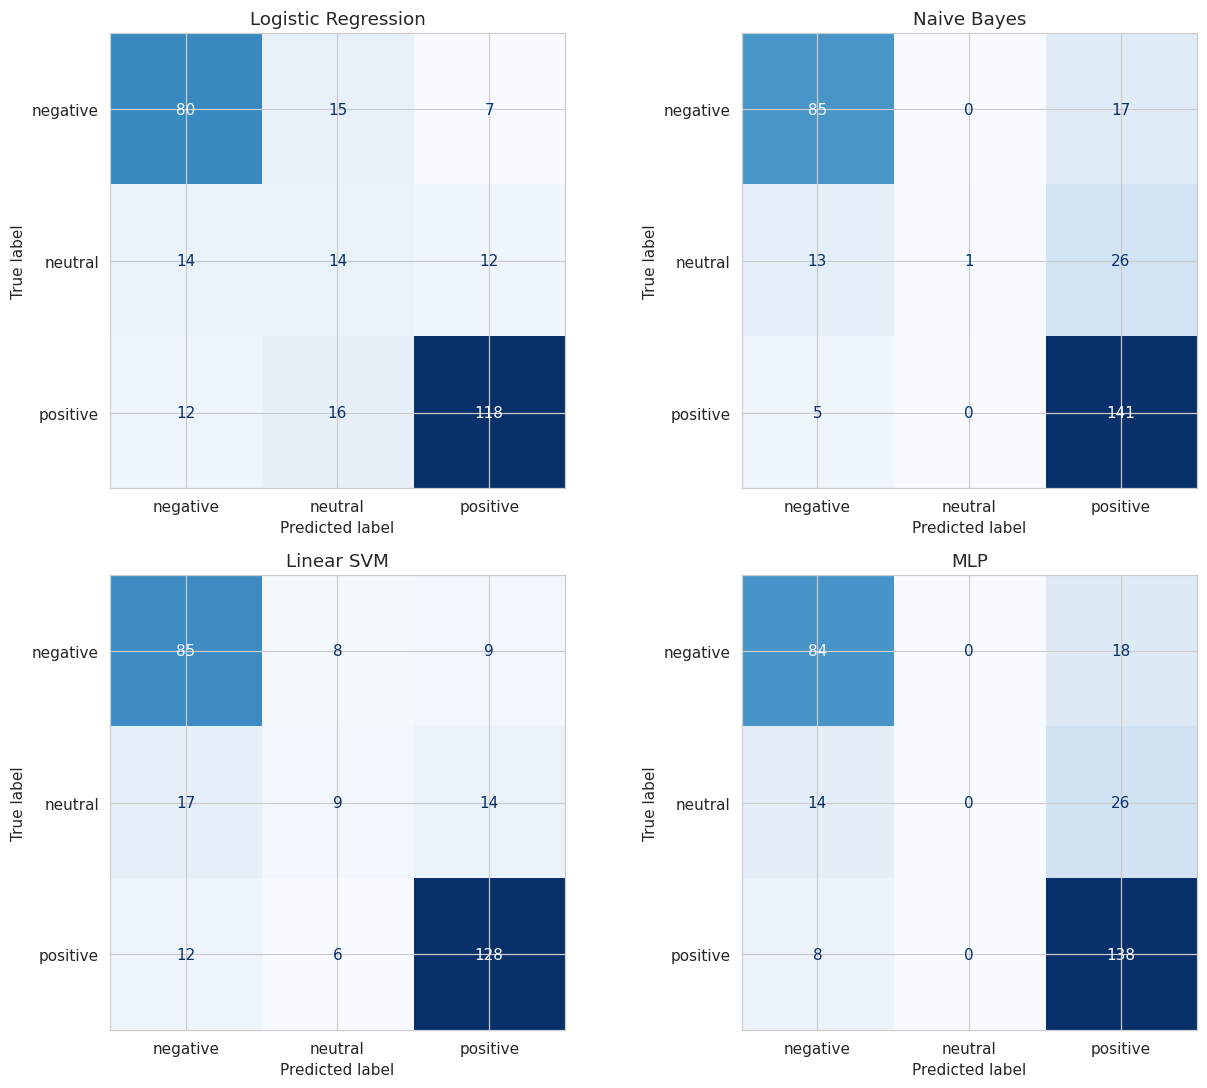

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (model_name, pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    )
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(model_name)

plt.tight_layout()
plt.show()

## 20. Model Comparison

Here we compare the four models using the same evaluation metrics.

we mainly look at **Macro-F1** because all three sentiment classes are important. I also compare accuracy and the other evaluation measures.

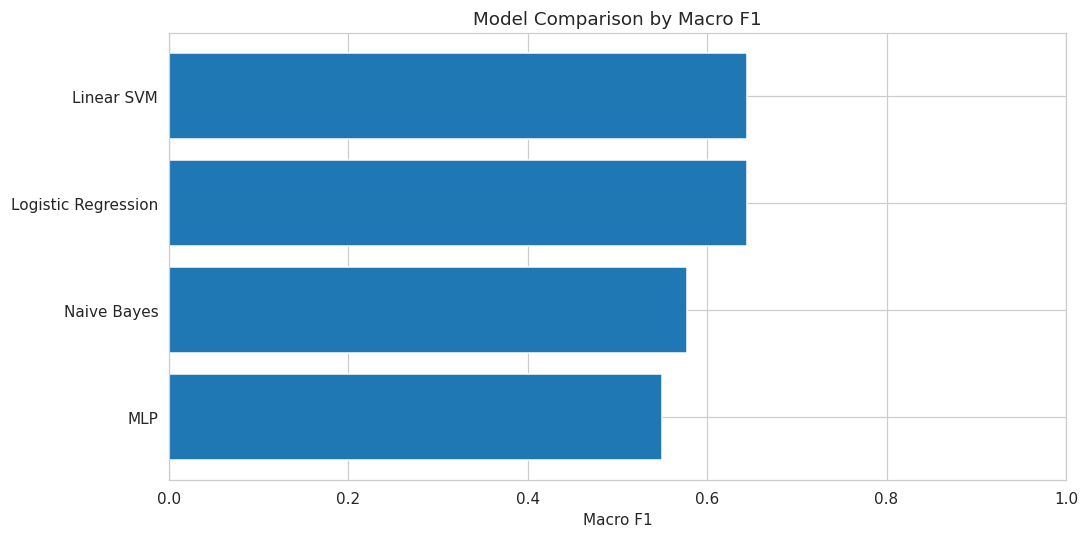

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Linear SVM,0.7708,0.6615,0.6450,0.6449,0.7554
1,Logistic Regression,0.7361,0.6424,0.6475,0.6442,0.7409
2,Naive Bayes,0.7882,0.8638,0.6080,0.5775,0.7337
3,MLP,0.7708,0.5169,0.5896,0.5497,0.7126


In [ ]:
plt.figure(figsize=(10, 5))
plot_df = evaluation_df.sort_values("Macro F1", ascending=True)

plt.barh(plot_df["Model"], plot_df["Macro F1"])
plt.xlabel("Macro F1")
plt.title("Model Comparison by Macro F1")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

display(
    evaluation_df[
        ["Model", "Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "Weighted F1"]
    ].round(4)
)

## 21. Does Handcrafted Feature Engineering Help?

I compare two versions:

- **TF-IDF only**
- **TF-IDF + handcrafted numerical features**

In [ ]:
ablation_models = {
    "TF-IDF only": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),
    "TF-IDF + Numeric": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    )
}

ablation_rows = []

for name, estimator in ablation_models.items():
    use_numeric = name == "TF-IDF + Numeric"

    pipeline = Pipeline([
        ("preprocessor", make_preprocessor(use_numeric=use_numeric)),
        ("model", estimator)
    ])

    # Tune only C for a compact and reproducible ablation.
    search = GridSearchCV(
        pipeline,
        param_grid={"model__C": [0.5, 1.0, 2.0]},
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1
    )
    search.fit(X_train, y_train)

    pred = search.best_estimator_.predict(X_test)

    ablation_rows.append({
        "Feature Set": name,
        "Best CV Macro F1": search.best_score_,
        "Test Accuracy": accuracy_score(y_test, pred),
        "Test Macro F1": f1_score(y_test, pred, average="macro", zero_division=0),
        "Test Weighted F1": f1_score(y_test, pred, average="weighted", zero_division=0),
        "Best C": search.best_params_["model__C"]
    })

ablation_df = pd.DataFrame(ablation_rows)
display(ablation_df.round(4))

,Feature Set,Best CV Macro F1,Test Accuracy,Test Macro F1,Test Weighted F1,Best C
0,TF-IDF only,0.6149,0.7917,0.6289,0.7586,2.0
1,TF-IDF + Numeric,0.6147,0.7882,0.6261,0.7553,2.0


## 22. Error Analysis

The purpose of error analysis is to understand **why** the model makes mistakes.

Some possible difficult cases are:

- Reviews containing both positive and negative opinions
- Negation such as “not good”
- Very short reviews with little context
- Reviews where the rating and text sentiment may not completely agree
- Complex or ambiguous language

Looking at these errors helps me understand the limitations of the current approach and identify areas for future improvement.

In [ ]:
best_model_name = evaluation_df.iloc[0]["Model"]
best_model = tuned_models[best_model_name]
best_pred = predictions[best_model_name]

error_analysis = X_test.copy()
error_analysis["actual"] = y_test.values
error_analysis["predicted"] = best_pred
error_analysis["actual_sentiment"] = label_encoder.inverse_transform(error_analysis["actual"])
error_analysis["predicted_sentiment"] = label_encoder.inverse_transform(error_analysis["predicted"])
error_analysis["is_error"] = error_analysis["actual"] != error_analysis["predicted"]

errors = error_analysis[error_analysis["is_error"]].copy()

print("Best model:", best_model_name)
print("Total test errors:", len(errors))
print("Test error rate:", round(len(errors) / len(error_analysis), 4))

display(
    errors[
        ["clean_text", "actual_sentiment", "predicted_sentiment"]
    ].head(20)
)

Best model: Linear SVM
Total test errors: 66
Test error rate: 0.2292


,clean_text,actual_sentiment,predicted_sentiment
173,not expecting would expect witha battery size 5000 great well okay not great think due size battery phone feel quite...,neutral,negative
402,budget mobile model samsung m12 6gb ram 128 rom black bought 10 350rsbattery life 10fingerprint face recognition 10c...,positive,neutral
1003,android phone not smart phone delay screen response no compass app run basic requirement compass app meet front came...,negative,neutral
871,display mediocre price okay display not mark dedicated sd slot expand memory also two sims meet requirement quite ha...,positive,negative
605,phone heavy camera quality not good phone camera not worth quality mentioned device also weight rethink want buy not...,neutral,negative
1120,samsung forcing use app remove smasung apps delete samsung forcing use really disappointed hand apple allows delete ...,neutral,negative
239,good phone performance not smooth liked phone battery last long even tool 6gb ram version phone little sluggish perf...,neutral,positive
234,ok budget phone not made china purchased june like battery power charge day medium heavy user big thumb storage capa...,neutral,negative
252,not good advertised contact book not large around 700 contact yet take couple second load happen previous mobile eve...,negative,positive
277,budgeted phone ever budgeted phone gb 128 gb storage variant good battery backup awesome took hr full charge not hap...,neutral,positive


### Error Distribution by Actual and Predicted Class

This table and chart show how the errors of the best model are distributed between the actual and predicted sentiment classes.

we can use this to identify the most common type of mistake. For example, if many Neutral reviews are predicted as Positive, that tells me the model has difficulty separating those two classes.

This gives me more information than a single overall accuracy value.

predicted_sentiment,negative,neutral,positive
actual_sentiment,,,
negative,0,8,9
neutral,17,0,14
positive,12,6,0


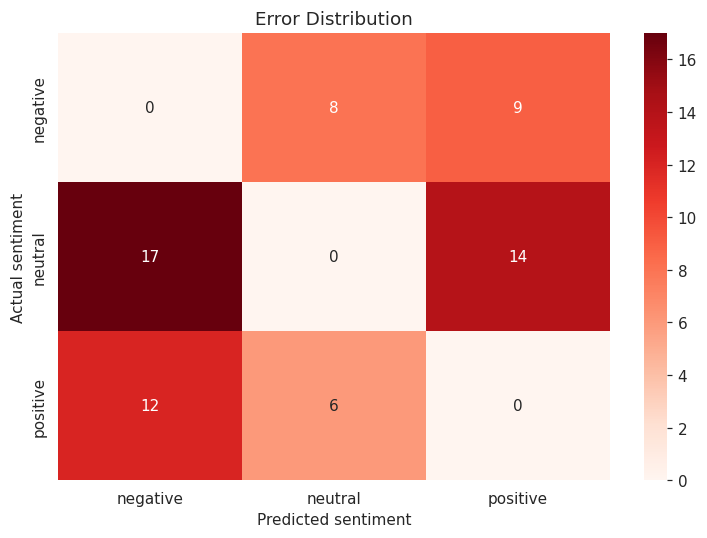

In [ ]:
error_counts = pd.crosstab(
    errors["actual_sentiment"],
    errors["predicted_sentiment"]
)

display(error_counts)

plt.figure(figsize=(7, 5))
sns.heatmap(error_counts, annot=True, fmt="d", cmap="Reds")
plt.xlabel("Predicted sentiment")
plt.ylabel("Actual sentiment")
plt.title("Error Distribution")
plt.tight_layout()
plt.show()

## 23. Targeted Prediction Tests

we also test the final prediction function with a few manually written reviews.

we include examples such as clearly positive and negative reviews, as well as more difficult cases involving negation and mixed sentiment.


In [ ]:
test_reviews = [
    "This phone is amazing. Battery backup is excellent.",
    "Worst phone ever. Battery drains very quickly and camera quality is terrible.",
    "The phone is okay. Performance is average for the price.",
    "The camera is not good.",
    "The battery is not bad at all.",
    "Excellent battery but terrible camera.",
    "I never expected such poor quality.",
    "The phone is good!!!"
]

def predict_with_model(model, review_text):
    frame = pd.DataFrame([{
        "clean_text": clean_text_pipeline(review_text),
        **create_numeric_features(review_text)
    }])
    prediction = model.predict(frame)[0]
    return label_encoder.inverse_transform([prediction])[0]

prediction_test_rows = []

for review in test_reviews:
    row = {"Review": review}
    for model_name, model in tuned_models.items():
        row[model_name] = predict_with_model(model, review)
    prediction_test_rows.append(row)

prediction_tests_df = pd.DataFrame(prediction_test_rows)
display(prediction_tests_df)

,Review,Logistic Regression,Naive Bayes,Linear SVM,MLP
0,This phone is amazing. Battery backup is excellent.,positive,positive,positive,positive
1,Worst phone ever. Battery drains very quickly and camera quality is terrible.,negative,negative,negative,negative
2,The phone is okay. Performance is average for the price.,neutral,positive,neutral,positive
3,The camera is not good.,neutral,positive,neutral,positive
4,The battery is not bad at all.,neutral,positive,negative,negative
5,Excellent battery but terrible camera.,positive,positive,positive,positive
6,I never expected such poor quality.,negative,negative,negative,negative
7,The phone is good!!!,positive,positive,positive,positive


## 24. Cross-Validation Stability of the Selected Models

Cross-validation gives me an estimate of how consistently the model performs on different training and validation splits.

Here we compare the best cross-validation Macro-F1 with the final Macro-F1 obtained on the untouched test set.

In [ ]:
stability_df = tuning_df.merge(
    evaluation_df[["Model", "Macro F1", "Accuracy"]],
    on="Model",
    how="left"
).rename(columns={
    "Macro F1": "Test Macro F1",
    "Accuracy": "Test Accuracy"
})

stability_df["CV-Test Macro F1 Gap"] = (
    stability_df["Best CV Macro-F1"] - stability_df["Test Macro F1"]
)

display(
    stability_df[
        ["Model", "Best CV Macro-F1", "Test Macro F1", "CV-Test Macro F1 Gap", "Test Accuracy"]
    ].round(4)
)

,Model,Best CV Macro-F1,Test Macro F1,CV-Test Macro F1 Gap,Test Accuracy
0,Logistic Regression,0.6905,0.6442,0.0463,0.7361
1,Linear SVM,0.6573,0.6449,0.0124,0.7708
2,MLP,0.5864,0.5497,0.0367,0.7708
3,Naive Bayes,0.5541,0.5775,-0.0234,0.7882


## 25. Model Saving — Complete Pipelines

After training, we save each complete model pipeline rather than saving only the classifier.

Saving the complete pipeline reduces the chance of using a model with different preprocessing later when I deploy or test it.

In [ ]:
os.makedirs("saved_models", exist_ok=True)

for model_name, model in tuned_models.items():
    safe_name = re.sub(r"[^a-z0-9]+", "_", model_name.lower()).strip("_")
    output_path = os.path.join("saved_models", f"{safe_name}_pipeline.joblib")
    joblib.dump(model, output_path)
    print("Saved:", output_path)

joblib.dump(label_encoder, "saved_models/label_encoder.joblib")

metadata = {
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "cv_folds": CV_FOLDS,
    "sentiment_mapping": {
        "1-2": "negative",
        "3": "neutral",
        "4-5": "positive"
    },
    "numeric_features": numeric_feature_cols,
    "tfidf_max_features": 5000,
    "tfidf_ngram_range": (1, 2),
    "labels_are_rating_derived": True
}

joblib.dump(metadata, "saved_models/model_metadata.joblib")
print("Saved model metadata.")

Saved: saved_models/logistic_regression_pipeline.joblib
Saved: saved_models/naive_bayes_pipeline.joblib
Saved: saved_models/linear_svm_pipeline.joblib
Saved: saved_models/mlp_pipeline.joblib
Saved model metadata.


## 26.Prediction Function

created a reusable `predict_sentiment()` function so that I can give it a new review and receive a sentiment prediction.

The function uses the selected trained pipeline, so the new review automatically goes through the same preprocessing and feature extraction steps used during training.

This makes the notebook easier to extend into an application or API in the future.

In [ ]:
def predict_sentiment(review_text, model_name=None):
    if model_name is None:
        model_name = best_model_name

    if model_name not in tuned_models:
        raise ValueError(
            f"Unknown model '{model_name}'. Choose from: {list(tuned_models.keys())}"
        )

    model = tuned_models[model_name]

    frame = pd.DataFrame([{
        "clean_text": clean_text_pipeline(review_text),
        **create_numeric_features(review_text)
    }])

    prediction = model.predict(frame)[0]
    sentiment = label_encoder.inverse_transform([prediction])[0]

    result = {
        "model": model_name,
        "sentiment": sentiment
    }

    # Add confidence-like information when the model exposes probabilities.
    if hasattr(model, "predict_proba"):
        probability = model.predict_proba(frame)[0]
        result["confidence"] = float(np.max(probability))

    return result

print(predict_sentiment(" PHONE IS OKAY,BUT BATTERY IS NOT GOOD."))

{'model': 'Linear SVM', 'sentiment': 'neutral'}


## 27. Conclusion:

The final test results show that Naive Bayes achieved the highest overall accuracy of 78.82%. However, Linear SVM achieved the highest Macro-F1 score of 64.49%, followed very closely by Logistic Regression with 64.42%. Since Macro-F1 gives equal importance to Negative, Neutral and Positive classes, it provides a more balanced view of performance when the classes are not equally distributed. Therefore, Linear SVM is the most suitable model in this experiment when considering balanced classification performance.

The cross-validation stability analysis also supports Linear SVM. Its CV Macro-F1 was 0.6573 compared with a test Macro-F1 of 0.6449, giving a relatively small CV-test gap of 0.0124. This indicates that its validation and unseen-test performance are reasonably consistent. The other models showed larger differences between their cross-validation and test performance.

The error analysis showed that the model has difficulty with reviews containing mixed opinions, negation, ambiguous language and cases where the text and rating may not completely agree. These observations show that traditional TF-IDF-based models can perform well on general sentiment classification but may struggle to understand more complex language patterns.

Overall, the project demonstrates that traditional machine-learning techniques can provide useful sentiment classification performance without requiring a large deep-learning model. Among the tested models, Linear SVM provides the best balance of Macro-F1 performance and generalization stability for this dataset.

However, the results should be interpreted with an important limitation: the sentiment labels in this project were generated from star ratings rather than independently annotated from the review text. Therefore, the reported performance measures how well the models reproduce the sentiment categories derived from ratings. Future work could improve the system by using a larger dataset with human-annotated sentiment labels, performing more detailed error analysis, and exploring advanced transformer-based NLP models for handling context, negation and mixed sentiment more effectively.

## Deployment

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import re
from scipy.sparse import hstack

# ----------------------------------------------------
# 1. Page Configuration & Custom UI Styling
# ----------------------------------------------------
st.set_page_config(
    page_title="Review Sentiment AI | Linear SVM",
    page_icon="📱",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Custom CSS for modern styling
st.markdown("""
    <style>
        .main-header {
            font-size: 2.3rem;
            font-weight: 700;
            color: #1E3A8A;
            margin-bottom: 0.2rem;
        }
        .sub-header {
            font-size: 1.05rem;
            color: #4B5563;
            margin-bottom: 1.5rem;
        }
        .metric-card {
            background-color: #F8FAFC;
            border-radius: 10px;
            padding: 15px;
            border: 1px solid #E2E8F0;
            text-align: center;
        }
        .stAlert {
            border-radius: 8px;
        }
    </style>
""", unsafe_allow_html=True)

# ----------------------------------------------------
# 2. Text Preprocessing & Artifact Loading
# ----------------------------------------------------
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

@st.cache_resource
def load_all_artifacts():
    artifacts = {}
    try:
        artifacts['model'] = joblib.load("linear_svm_model.pkl")
        artifacts['encoder'] = joblib.load("label_encoder.pkl")

        # Optional helper artifacts if present
        for name in ['tfidf_vectorizer', 'numeric_scaler', 'feature_columns']:
            try:
                artifacts[name] = joblib.load(f"{name}.pkl")
            except Exception:
                artifacts[name] = None

        return artifacts, True
    except Exception as e:
        return {"error": str(e)}, False

artifacts, is_loaded = load_all_artifacts()

# ----------------------------------------------------
# 3. Model Inference Helper
# ----------------------------------------------------
def predict_dataframe(df_input):
    """
    Handles both direct pipeline input and manual feature matrix generation.
    """
    model = artifacts['model']
    encoder = artifacts['encoder']

    # Ensure standard text and length columns exist
    df_proc = df_input.copy()
    if 'title' not in df_proc.columns:
        df_proc['title'] = ""
    if 'body' not in df_proc.columns:
        df_proc['body'] = df_proc.iloc[:, 0].astype(str)

    df_proc['title'] = df_proc['title'].astype(str)
    df_proc['body'] = df_proc['body'].astype(str)

    df_proc['title_char_len'] = df_proc['title'].str.len()
    df_proc['body_char_len'] = df_proc['body'].str.len()
    df_proc['title_word_count'] = df_proc['title'].apply(lambda x: len(str(x).split()))
    df_proc['body_word_count'] = df_proc['body'].apply(lambda x: len(str(x).split()))

    # 1. Try passing the full feature DataFrame (for ColumnTransformer / Pipeline)
    try:
        preds = model.predict(df_proc)
    except Exception:
        # 2. Try manual stacking if TF-IDF & Scaler are separate
        if artifacts.get('tfidf_vectorizer') is not None and artifacts.get('numeric_scaler') is not None:
            tfidf = artifacts['tfidf_vectorizer']
            scaler = artifacts['numeric_scaler']

            cleaned_bodies = df_proc['body'].apply(clean_text)
            text_vec = tfidf.transform(cleaned_bodies)

            # Scale numeric features
            num_cols = ['title_char_len', 'body_char_len', 'title_word_count', 'body_word_count']
            num_scaled = scaler.transform(df_proc[num_cols])

            X_input = hstack([text_vec, num_scaled])
            preds = model.predict(X_input)
        elif artifacts.get('tfidf_vectorizer') is not None:
            # 3. Fallback: TF-IDF only
            tfidf = artifacts['tfidf_vectorizer']
            cleaned_bodies = df_proc['body'].apply(clean_text)
            X_input = tfidf.transform(cleaned_bodies)
            preds = model.predict(X_input)
        else:
            raise ValueError("Could not match the input format required by the model.")

    # Decode labels
    if hasattr(encoder, 'inverse_transform'):
        labels = encoder.inverse_transform(preds)
    else:
        labels = preds

    return [str(l).capitalize() for l in labels]

# ----------------------------------------------------
# 4. App Header & Sidebar Navigation
# ----------------------------------------------------
st.markdown('<div class="main-header">📱 Sentiment Analysis Dashboard</div>', unsafe_allow_html=True)
st.markdown('<div class="sub-header">Classify Amazon Mobile Reviews into <b>Positive</b>, <b>Neutral</b>, or <b>Negative</b> using Linear SVM.</div>', unsafe_allow_html=True)

if not is_loaded:
    st.error(f"⚠️ Failed to load model artifacts: {artifacts.get('error')}. Please ensure all `.pkl` files are in the working directory.")
    st.stop()

with st.sidebar:
    st.title("⚙️ Options")
    mode = st.radio("Select Prediction Mode:", ["Single Review", "Bulk Upload (CSV / Excel)"], index=0)
    st.markdown("---")
    st.markdown("### ℹ️ Model Details")
    st.markdown("""
    - **Classifier:** Linear SVM (`LinearSVC`)
    - **Features:** TF-IDF & Engineered Text Features
    - **Classes:** Negative, Neutral, Positive
    """)
    st.markdown("---")
    st.caption("Developed with Streamlit & Scikit-Learn")

# ----------------------------------------------------
# 5. Mode 1: Single Review Prediction
# ----------------------------------------------------
if mode == "Single Review":
    st.subheader("🔍 Single Review Classification")

    with st.container():
        col_title, col_body = st.columns([1, 2])
        with col_title:
            review_title = st.text_input("Review Title", placeholder="e.g., Value for money / Poor battery")
        with col_body:
            review_body = st.text_area("Review Body", placeholder="e.g., The phone's battery life is amazing and camera quality is top-notch!", height=120)

        # Real-time feature preview metrics
        c1, c2, c3, c4 = st.columns(4)
        c1.metric("Title Chars", len(review_title))
        c2.metric("Title Words", len(review_title.split()))
        c3.metric("Body Chars", len(review_body))
        c4.metric("Body Words", len(review_body.split()))

        if st.button("🚀 Analyze Sentiment", type="primary", use_container_width=True):
            if not review_body.strip() and not review_title.strip():
                st.warning("Please enter review title or body text.")
            else:
                sample_df = pd.DataFrame({
                    'title': [review_title],
                    'body': [review_body]
                })

                with st.spinner("Analyzing text..."):
                    prediction = predict_dataframe(sample_df)[0]

                st.markdown("### Result")
                if prediction.lower() == "positive":
                    st.success(f"### 🎉 Sentiment: **{prediction}**")
                elif prediction.lower() == "negative":
                    st.error(f"### ⚠️ Sentiment: **{prediction}**")
                else:
                    st.warning(f"### ⚖️ Sentiment: **{prediction}**")

# ----------------------------------------------------
# 6. Mode 2: Bulk CSV / Excel File Upload
# ----------------------------------------------------
else:
    st.subheader("📁 Bulk Review Analysis")
    st.markdown("Upload a CSV or Excel file containing a column of customer reviews (e.g., `body`, `review`, or `text`).")

    uploaded_file = st.file_uploader("Choose a CSV or Excel file", type=["csv", "xlsx"])

    if uploaded_file is not None:
        try:
            if uploaded_file.name.endswith(".csv"):
                df_upload = pd.read_csv(uploaded_file)
            else:
                df_upload = pd.read_excel(uploaded_file)

            st.write(f"**Loaded {len(df_upload)} rows.** Preview of raw data:")
            st.dataframe(df_upload.head(4), use_container_width=True)

            # Select target review column
            col1, col2 = st.columns(2)
            with col1:
                title_col = st.selectbox("Select Title Column (Optional)", ["None"] + list(df_upload.columns))
            with col2:
                # Default to 'body' if present, otherwise first object column
                default_idx = 0
                for idx, c in enumerate(df_upload.columns):
                    if c.lower() in ['body', 'review', 'text', 'comment']:
                        default_idx = idx
                        break
                body_col = st.selectbox("Select Review Body Column", list(df_upload.columns), index=default_idx)

            if st.button("📊 Process All Reviews", type="primary"):
                with st.spinner(f"Classifying {len(df_upload)} reviews..."):
                    eval_df = pd.DataFrame()
                    eval_df['title'] = df_upload[title_col] if title_col != "None" else ""
                    eval_df['body'] = df_upload[body_col]

                    df_upload['Predicted_Sentiment'] = predict_dataframe(eval_df)

                st.success("✅ Classification completed!")
                st.divider()

                # Metrics Overview
                counts = df_upload['Predicted_Sentiment'].value_counts()
                total = len(df_upload)

                m1, m2, m3, m4 = st.columns(4)
                m1.metric("Total Reviews", total)
                m2.metric("Positive 😊", counts.get("Positive", 0), f"{(counts.get('Positive', 0)/total)*100:.1f}%")
                m3.metric("Neutral 😐", counts.get("Neutral", 0), f"{(counts.get('Neutral', 0)/total)*100:.1f}%")
                m4.metric("Negative 😡", counts.get("Negative", 0), f"{(counts.get('Negative', 0)/total)*100:.1f}%")

                # Chart Distribution
                st.markdown("#### Sentiment Distribution")
                st.bar_chart(counts)

                # Detailed Data Table
                st.markdown("#### Detailed Results")
                st.dataframe(df_upload, use_container_width=True)

                # Export Button
                csv_data = df_upload.to_csv(index=False).encode('utf-8')
                st.download_button(
                    label="📥 Download Classified Results as CSV",
                    data=csv_data,
                    file_name="sentiment_predictions.csv",
                    mime="text/csv"
                )

        except Exception as err:
            st.error(f"Error processing file: {err}")

Overwriting app.py


In [ ]:
import os

required_files = [
    "app.py",
    "tfidf_vectorizer.pkl",
    "label_encoder.pkl",
    "linear_svm_model.pkl"
]

for file in required_files:
    if os.path.exists(file):
        print("✅", file)
    else:
        print("❌", file, "-> Missing! Please save/upload this file.")

✅ app.py
✅ tfidf_vectorizer.pkl
✅ label_encoder.pkl
✅ linear_svm_model.pkl


In [ ]:
from sklearn.svm import LinearSVC
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer

# Instantiate and fit TF-IDF vectorizer using the same parameters as in make_preprocessor
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.90,
    sublinear_tf=True
)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train['clean_text'])

# Fit Linear SVM directly on TF-IDF features
svm_text_model = LinearSVC(C=1.0, random_state=42)
svm_text_model.fit(X_train_tfidf, y_train)

# Save the text-only model and the TF-IDF vectorizer
joblib.dump(svm_text_model, "linear_svm_model.pkl")
joblib.dump(tfidf_vectorizer, "tfidf_vectorizer.pkl")

print("✅ Text-only Linear SVM and TF-IDF vectorizer saved successfully!")

✅ Text-only Linear SVM and TF-IDF vectorizer saved successfully!


In [ ]:
import joblib
import pandas as pd
import re

# 1. Load all artifacts relevant for the text-only Linear SVM model
tfidf = joblib.load("tfidf_vectorizer.pkl")
encoder = joblib.load("label_encoder.pkl")
model = joblib.load("linear_svm_model.pkl")

# 2. Define a sample review text
sample_review_text = 'Great display, long battery life, totally worth the price!'

# 3. Clean the sample text using the existing clean_text_pipeline function
# (Assuming clean_text_pipeline is defined in a previous cell and accessible)
cleaned_text_sample = clean_text_pipeline(sample_review_text)

# 4. Vectorize the cleaned text using the loaded TF-IDF vectorizer
vectorized_text_sample = tfidf.transform([cleaned_text_sample])

# 5. Make a prediction using the loaded model
prediction_encoded = model.predict(vectorized_text_sample)

# 6. Decode the prediction to get the sentiment label
predicted_label = encoder.inverse_transform(prediction_encoded)[0]

print("✅ Test Prediction:", predicted_label)

✅ Test Prediction: positive


In [ ]:
!pip install -q streamlit pyngrok

In [ ]:
!streamlit run app.py &> /content/streamlit.log &

In [ ]:
from pyngrok import ngrok

# Set your ngrok authtoken (replace with your token if needed)
ngrok.set_auth_token("3BKidkRjf0VI7XCgB7Gn9DWZHYD_3VG9gEBJJPjepfg1i3UWJ")

# Open tunnel on Streamlit default port 8501
public_url = ngrok.connect(8501)
print(f"🚀 Streamlit App is live at: {public_url}")

🚀 Streamlit App is live at: NgrokTunnel: "https://unimproved-uncontributively-marleen.ngrok-free.dev" -> "http://localhost:8501"
